# Network kernel density on Manhattan road edges

1. Snap TLC pickups to OSMnx edges and aggregate `demand_count` → `data/processed/edges_with_demand.gpkg`
2. Compute network KDE (NKDE) with a 500 m quadratic kernel, apply `log1p`, normalize to 0–1 → `data/processed/edges_with_nkde.gpkg`

In [ ]:
from pathlib import Path

import geopandas as gpd
import numpy as np
import osmnx as ox

TARGET_CRS = "EPSG:2263"
CHUNK_SIZE = 100_000

# --- paths (works from repo root or notebooks/) ---
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PICKUPS_PATH = PROJECT_ROOT / "data/processed/tlc_2010_manhattan_pickups.parquet"
OUT_PATH = PROJECT_ROOT / "data/processed/edges_with_demand.gpkg"

def _first_existing(*paths: Path) -> Path:
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError(f"None of these paths exist: {', '.join(map(str, paths))}")

ROADS_PATH = _first_existing(
    PROJECT_ROOT / "data/raw/manhattan_roads.gpkg",
    PROJECT_ROOT / "notebooks/data/raw/manhattan_roads.gpkg",
)
NODES_PATH = _first_existing(
    PROJECT_ROOT / "data/raw/manhattan_nodes.gpkg",
    PROJECT_ROOT / "notebooks/data/raw/manhattan_nodes.gpkg",
)


def _load_graph_from_gpkg(roads_path: Path, nodes_path: Path, target_crs: str):
    """Rebuild OSMnx graph from saved node/edge GeoPackages in target_crs."""
    edges = gpd.read_file(roads_path)
    nodes = gpd.read_file(nodes_path)

    if edges.crs is None or nodes.crs is None:
        raise ValueError("Road network GeoPackages must define a CRS.")
    if str(edges.crs) != target_crs:
        edges = edges.to_crs(target_crs)
    if str(nodes.crs) != target_crs:
        nodes = nodes.to_crs(target_crs)

    # graph_from_gdfs expects x/y to match geometry after reprojection
    nodes["x"] = nodes.geometry.x
    nodes["y"] = nodes.geometry.y

    nodes = nodes.set_index("osmid", drop=False)
    edges_idx = edges.set_index(["u", "v", "key"])

    G = ox.graph_from_gdfs(nodes, edges_idx)
    return G, edges


# 1. Load pickups if not already in memory
if "gdf_mht_pu" in globals():
    gdf_pickups = globals()["gdf_mht_pu"]
    print(f"Using in-memory gdf_mht_pu ({len(gdf_pickups):,} rows)")
else:
    gdf_pickups = gpd.read_parquet(PICKUPS_PATH)
    print(f"Loaded pickups from {PICKUPS_PATH} ({len(gdf_pickups):,} rows)")

if gdf_pickups.crs is None:
    raise ValueError("Pickups GeoDataFrame has no CRS.")
if str(gdf_pickups.crs) != TARGET_CRS:
    gdf_pickups = gdf_pickups.to_crs(TARGET_CRS)

# 2. Load road network if not already in memory
if "G" in globals() and "edges" in globals():
    G = globals()["G"]
    edges = globals()["edges"].copy()
    print(f"Using in-memory G and edges ({len(edges):,} edges)")
    if str(edges.crs) != TARGET_CRS:
        edges = edges.to_crs(TARGET_CRS)
        nodes_gdf, edges_idx = ox.graph_to_gdfs(G)
        nodes_gdf = nodes_gdf.to_crs(TARGET_CRS)
        nodes_gdf["x"] = nodes_gdf.geometry.x
        nodes_gdf["y"] = nodes_gdf.geometry.y
        G = ox.graph_from_gdfs(
            nodes_gdf.set_index("osmid", drop=False),
            edges.to_crs(TARGET_CRS).set_index(["u", "v", "key"]),
        )
else:
    G, edges = _load_graph_from_gpkg(ROADS_PATH, NODES_PATH, TARGET_CRS)
    print(f"Loaded graph from {ROADS_PATH.name} ({len(edges):,} edges, CRS {edges.crs})")

# 3–4. Snap pickups to nearest edges in chunks; store edge_u / edge_v
n = len(gdf_pickups)
edge_u = np.empty(n, dtype=np.int64)
edge_v = np.empty(n, dtype=np.int64)

print(f"Snapping {n:,} pickups in chunks of {CHUNK_SIZE:,}...")
for start in range(0, n, CHUNK_SIZE):
    end = min(start + CHUNK_SIZE, n)
    chunk = gdf_pickups.iloc[start:end]
    X = chunk.geometry.x.to_numpy()
    Y = chunk.geometry.y.to_numpy()

    uvk = ox.nearest_edges(G, X, Y)
    edge_u[start:end] = np.fromiter((t[0] for t in uvk), dtype=np.int64, count=end - start)
    edge_v[start:end] = np.fromiter((t[1] for t in uvk), dtype=np.int64, count=end - start)

    print(f"  {end:,} / {n:,} ({100 * end / n:.1f}%)")

gdf_pickups = gdf_pickups.copy()
gdf_pickups["edge_u"] = edge_u
gdf_pickups["edge_v"] = edge_v

# 5. Pickup counts per (u, v) edge pair
demand = (
    gdf_pickups.groupby(["edge_u", "edge_v"], as_index=False)
    .size()
    .rename(columns={"size": "demand_count"})
)
print(f"Unique (u, v) pairs with demand: {len(demand):,}")

# 6–7. Join demand onto edges; fill missing with 0
edges_out = edges.merge(
    demand,
    left_on=["u", "v"],
    right_on=["edge_u", "edge_v"],
    how="left",
)
edges_out = edges_out.drop(columns=["edge_u", "edge_v"], errors="ignore")
edges_out["demand_count"] = edges_out["demand_count"].fillna(0).astype(np.int64)

# 8. Summary stats
total_edges = len(edges_out)
nonzero = int((edges_out["demand_count"] > 0).sum())
dc = edges_out["demand_count"]
print(f"Total edges: {total_edges:,}")
print(f"Edges with non-zero demand: {nonzero:,}")
print(f"demand_count min: {dc.min()}")
print(f"demand_count max: {dc.max()}")
print(f"demand_count mean: {dc.mean():.2f}")

# 9. Save enriched network
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
edges_out.to_file(OUT_PATH, driver="GPKG")
print(f"Saved -> {OUT_PATH.resolve()}")

## Network KDE (NKDE)

For each edge, sum `demand_count` on all edges within 500 m network distance, weighted by `(1 - d/500)²`. Run on a 20% sample first, then all edges.

In [2]:
from collections import defaultdict
from pathlib import Path
import time

import geopandas as gpd
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd

# Self-contained if you skip the demand-snapping cell above
if "PROJECT_ROOT" not in globals():

    def _first_existing(*paths):
        for p in paths:
            if p.exists():
                return p
        raise FileNotFoundError(f"None of these paths exist: {', '.join(map(str, paths))}")

    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent
    TARGET_CRS = "EPSG:2263"
    ROADS_PATH = _first_existing(
        PROJECT_ROOT / "data/raw/manhattan_roads.gpkg",
        PROJECT_ROOT / "notebooks/data/raw/manhattan_roads.gpkg",
    )
    NODES_PATH = _first_existing(
        PROJECT_ROOT / "data/raw/manhattan_nodes.gpkg",
        PROJECT_ROOT / "notebooks/data/raw/manhattan_nodes.gpkg",
    )

BANDWIDTH_M = 500.0
SAMPLE_FRAC = 0.2
RNG_SEED = 42

EDGES_DEMAND_PATH = PROJECT_ROOT / "data/processed/edges_with_demand.gpkg"
NKDE_OUT_PATH = PROJECT_ROOT / "data/processed/edges_with_nkde.gpkg"


def quadratic_kernel(dist_m: float, bandwidth_m: float = BANDWIDTH_M) -> float:
    if dist_m >= bandwidth_m:
        return 0.0
    return (1.0 - dist_m / bandwidth_m) ** 2


def _edge_network_distance(lengths: dict, u: int, v: int) -> float:
    """Shortest-path distance from origin node to edge (u, v) endpoints."""
    du = lengths.get(u)
    dv = lengths.get(v)
    if du is None and dv is None:
        return float("inf")
    if du is None:
        return dv
    if dv is None:
        return du
    return min(du, dv)


def compute_nkde_scores(
    G: nx.MultiDiGraph,
    edges_gdf: gpd.GeoDataFrame,
    *,
    bandwidth_m: float = BANDWIDTH_M,
    target_indices=None,
    length_cache=None,
) -> np.ndarray:
    """NKDE score per edge: sum_j demand_j * (1 - d_ij/bandwidth)^2 within bandwidth."""
    n_edges = len(edges_gdf)
    scores = np.zeros(n_edges, dtype=np.float64)

    if "length" not in next(iter(G.edges(data=True)))[2]:
        G = ox.distance.add_edge_lengths(G)

    edge_u = edges_gdf["u"].to_numpy()
    edge_v = edges_gdf["v"].to_numpy()
    demand = edges_gdf["demand_count"].to_numpy(dtype=np.float64)

    midpoints = edges_gdf.geometry.interpolate(0.5, normalized=True)
    nearest_nodes = ox.distance.nearest_nodes(
        G, midpoints.x.to_numpy(), midpoints.y.to_numpy()
    )
    nearest_nodes = np.asarray(nearest_nodes)

    node_incident_edges: dict[int, set[int]] = defaultdict(set)
    for j in range(n_edges):
        node_incident_edges[edge_u[j]].add(j)
        node_incident_edges[edge_v[j]].add(j)

    if target_indices is None:
        target_indices = np.arange(n_edges, dtype=np.int64)
    else:
        target_indices = np.asarray(target_indices, dtype=np.int64)

    if length_cache is None:
        length_cache = {}

    n_targets = len(target_indices)
    t0 = time.perf_counter()
    for k, i in enumerate(target_indices, start=1):
        i = int(i)
        origin_node = int(nearest_nodes[i])

        lengths = length_cache.get(origin_node)
        if lengths is None:
            lengths = nx.single_source_dijkstra_path_length(
                G,
                origin_node,
                cutoff=bandwidth_m,
                weight="length",
            )
            length_cache[origin_node] = lengths

        candidates: set[int] = set()
        for node in lengths:
            candidates.update(node_incident_edges[node])

        total = 0.0
        for j in candidates:
            d_ij = _edge_network_distance(lengths, edge_u[j], edge_v[j])
            if d_ij <= bandwidth_m:
                total += demand[j] * quadratic_kernel(d_ij, bandwidth_m)
        scores[i] = total

        if k % 2000 == 0 or k == n_targets:
            elapsed = time.perf_counter() - t0
            print(
                f"  edges {k:,} / {n_targets:,} "
                f"({100 * k / n_targets:.1f}%) — {elapsed:.1f}s"
            )

    return scores


def normalize_0_1(values: np.ndarray) -> np.ndarray:
    vmin, vmax = float(values.min()), float(values.max())
    if vmax <= vmin:
        return np.zeros_like(values, dtype=np.float64)
    return (values - vmin) / (vmax - vmin)


def print_nkde_stats(series: pd.Series, label: str) -> None:
    print(f"\n--- {label} ---")
    print(f"min:  {series.min():.6f}")
    print(f"max:  {series.max():.6f}")
    print(f"mean: {series.mean():.6f}")
    print(f"std:  {series.std():.6f}")
    print(series.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_string())


# 1. Load edges with demand
edges_demand = gpd.read_file(EDGES_DEMAND_PATH)
if str(edges_demand.crs) != TARGET_CRS:
    edges_demand = edges_demand.to_crs(TARGET_CRS)
print(f"Loaded {len(edges_demand):,} edges from {EDGES_DEMAND_PATH.name}")

# 2. Rebuild OSMnx graph (reuse in-memory G if available)
if "G" not in globals():
    if "_load_graph_from_gpkg" not in globals():

        def _load_graph_from_gpkg(roads_path, nodes_path, target_crs):
            edges_raw = gpd.read_file(roads_path)
            nodes_raw = gpd.read_file(nodes_path)
            if str(edges_raw.crs) != target_crs:
                edges_raw = edges_raw.to_crs(target_crs)
            if str(nodes_raw.crs) != target_crs:
                nodes_raw = nodes_raw.to_crs(target_crs)
            nodes_raw["x"] = nodes_raw.geometry.x
            nodes_raw["y"] = nodes_raw.geometry.y
            G_local = ox.graph_from_gdfs(
                nodes_raw.set_index("osmid", drop=False),
                edges_raw.set_index(["u", "v", "key"]),
            )
            return G_local, edges_raw

    G, _ = _load_graph_from_gpkg(ROADS_PATH, NODES_PATH, TARGET_CRS)
    print(f"Rebuilt graph from {ROADS_PATH.name} ({G.number_of_nodes():,} nodes)")
else:
    print(f"Using in-memory graph ({G.number_of_nodes():,} nodes)")

G = ox.project_graph(G, to_crs=TARGET_CRS)
if "length" not in next(iter(G.edges(data=True)))[2]:
    G = ox.distance.add_edge_lengths(G)

n_edges = len(edges_demand)
rng = np.random.default_rng(RNG_SEED)
sample_size = max(1, int(n_edges * SAMPLE_FRAC))
sample_idx = np.sort(rng.choice(n_edges, size=sample_size, replace=False))

# 4a. 20% sample run
print(f"\nNKDE sample run ({sample_size:,} edges, {SAMPLE_FRAC:.0%})...")
length_cache: dict = {}
raw_sample = compute_nkde_scores(
    G,
    edges_demand,
    target_indices=sample_idx,
    length_cache=length_cache,
)
log_sample = np.log1p(raw_sample[sample_idx])
norm_sample = normalize_0_1(log_sample)
print_nkde_stats(pd.Series(log_sample), "log1p(raw) on 20% sample")
print_nkde_stats(pd.Series(norm_sample), "nkde_score (20% sample, log1p + normalized)")

# 4b. Full network run (reuses Dijkstra cache from sample)
print(f"\nNKDE full run ({n_edges:,} edges)...")
raw_scores = compute_nkde_scores(
    G,
    edges_demand,
    length_cache=length_cache,
)
log_scores = np.log1p(raw_scores)
linear_norm = normalize_0_1(raw_scores)
log_norm = normalize_0_1(log_scores)

edges_nkde = edges_demand.copy()
edges_nkde["nkde_score"] = log_norm
nkde_score_linear_norm = linear_norm  # for before/after maps in next cell

# 7. Distribution statistics
print_nkde_stats(pd.Series(raw_scores), "raw NKDE (all edges)")
print_nkde_stats(pd.Series(log_scores), "log1p(raw NKDE, all edges)")
print_nkde_stats(edges_nkde["nkde_score"], "nkde_score (log1p + normalized 0-1)")

# 8. Save
NKDE_OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
edges_nkde.to_file(NKDE_OUT_PATH, driver="GPKG")
print(f"\nSaved -> {NKDE_OUT_PATH.resolve()}")

Loaded 9,916 edges from edges_with_demand.gpkg
Rebuilt graph from manhattan_roads.gpkg (4,628 nodes)

NKDE sample run (1,983 edges, 20%)...
  edges 1,983 / 1,983 (100.0%) — 0.6s

--- nkde_score (20% sample, normalized) ---
min:  0.000000
max:  1.000000
mean: 0.123443
std:  0.144700
count    1983.000000
mean        0.123443
std         0.144700
min         0.000000
25%         0.004598
50%         0.065582
75%         0.203461
90%         0.339833
95%         0.418642
99%         0.541901
max         1.000000

NKDE full run (9,916 edges)...
  edges 2,000 / 9,916 (20.2%) — 0.4s
  edges 4,000 / 9,916 (40.3%) — 0.9s
  edges 6,000 / 9,916 (60.5%) — 1.3s
  edges 8,000 / 9,916 (80.7%) — 1.6s
  edges 9,916 / 9,916 (100.0%) — 2.0s

--- nkde_score (all edges, normalized) ---
min:  0.000000
max:  1.000000
mean: 0.120799
std:  0.140888
count    9916.000000
mean        0.120799
std         0.140888
min         0.000000
25%         0.004832
50%         0.063931
75%         0.201483
90%         0.328

In [ ]:
# Score distributions + before/after maps (linear 0-1 vs log1p 0-1)
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

if "nkde_score_linear_norm" not in globals():
    raise RuntimeError("Run the NKDE cell above first.")

_root = Path.cwd()
if _root.name == "notebooks":
    _root = _root.parent
out_dir = _root / "data/outputs"
out_dir.mkdir(parents=True, exist_ok=True)

before = nkde_score_linear_norm
after = edges_nkde["nkde_score"].to_numpy()
log_raw = np.log1p(raw_scores)

# --- distributions ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(log_raw, bins=80, color="steelblue", edgecolor="white")
axes[0].set_title("log1p(raw NKDE)")
axes[0].set_xlabel("log1p(raw score)")
axes[0].set_ylabel("edge count")

axes[1].hist(after, bins=80, color="coral", edgecolor="white")
axes[1].set_title("nkde_score (log1p + normalized 0-1)")
axes[1].set_xlabel("nkde_score")
axes[1].set_ylabel("edge count")

plt.tight_layout()
dist_path = out_dir / "nkde_log_distribution.png"
plt.savefig(dist_path, dpi=150)
plt.show()
print(f"Saved -> {dist_path.resolve()}")

# --- spatial comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

edges_nkde.assign(nkde_linear=before).plot(
    column="nkde_linear",
    cmap="Reds",
    scheme="quantiles",
    k=7,
    legend=True,
    ax=axes[0],
)
axes[0].set_title("Before: linear normalize(raw)")
axes[0].axis("off")

edges_nkde.plot(
    column="nkde_score",
    cmap="Reds",
    scheme="quantiles",
    k=7,
    legend=True,
    ax=axes[1],
)
axes[1].set_title("After: normalize(log1p(raw))")
axes[1].axis("off")

plt.tight_layout()
compare_path = out_dir / "nkde_before_after_log.png"
plt.savefig(compare_path, dpi=150)
plt.show()
print(f"Saved -> {compare_path.resolve()}")

In [ ]:
# Validate output (paths work from repo root or notebooks/)
from pathlib import Path

import geopandas as gpd

_root = Path.cwd()
if _root.name == "notebooks":
    _root = _root.parent

nkde_path = _root / "data/processed/edges_with_nkde.gpkg"
demand_path = _root / "data/processed/edges_with_demand.gpkg"

edges_nkde = gpd.read_file(nkde_path)
edges_demand_check = gpd.read_file(demand_path)

print(f"Loaded: {nkde_path}")
print(edges_nkde[["demand_count", "nkde_score"]].describe())

# nkde_score is NOT a copy of demand_count — compare correlation and top edges
corr = edges_nkde["demand_count"].corr(edges_nkde["nkde_score"])
print(f"\nPearson correlation (demand_count vs nkde_score): {corr:.4f}")

top_demand = edges_nkde.nlargest(5, "demand_count")[["demand_count", "nkde_score"]]
top_nkde = edges_nkde.nlargest(5, "nkde_score")[["demand_count", "nkde_score"]]
print("\nTop 5 by demand_count:")
print(top_demand.to_string())
print("\nTop 5 by nkde_score:")
print(top_nkde.to_string())

# demand columns should match the source file exactly
demand_match = (
    edges_nkde["demand_count"].sort_index().values
    == edges_demand_check["demand_count"].sort_index().values
).all()
print(f"\ndemand_count unchanged from edges_with_demand.gpkg: {demand_match}")

In [17]:
# Check 1: did NKDE just copy demand_count? (paths work from repo root or notebooks/)
from pathlib import Path

import geopandas as gpd

_root = Path.cwd()
if _root.name == "notebooks":
    _root = _root.parent

nkde_path = _root / "data/processed/edges_with_nkde.gpkg"
edges = gpd.read_file(nkde_path)

print(f"Loaded: {nkde_path.resolve()}")
print(edges[["demand_count", "nkde_score"]].describe())

correlation = edges["demand_count"].corr(edges["nkde_score"])
print(f"\nCorrelation between demand_count and nkde_score: {correlation:.4f}")
# If correlation is exactly 1.0, NKDE just copied demand_count
# Expect high (e.g. 0.7–0.9) but not perfect

Loaded: C:\Users\Arv\OneDrive\Desktop\nyc-av-pudo-index\data\processed\edges_with_nkde.gpkg
       demand_count   nkde_score
count   9916.000000  9916.000000
mean    1376.897741     0.120799
std     2700.013379     0.140888
min        0.000000     0.000000
25%       13.000000     0.004832
50%      213.000000     0.063931
75%     1814.250000     0.201483
max    83234.000000     1.000000

Correlation between demand_count and nkde_score: 0.6487


In [18]:
 # Check 2: Did edges with zero demand get non-zero NKDE scores?
 # Edges with zero raw demand
zero_demand = edges[edges['demand_count'] == 0]

print(f"Edges with zero demand_count: {len(zero_demand)}")
print(f"Of those, edges with nkde_score > 0: {(zero_demand['nkde_score'] > 0).sum()}")
print(f"Mean nkde_score for zero-demand edges: {zero_demand['nkde_score'].mean():.4f}")

Edges with zero demand_count: 631
Of those, edges with nkde_score > 0: 629
Mean nkde_score for zero-demand edges: 0.0036


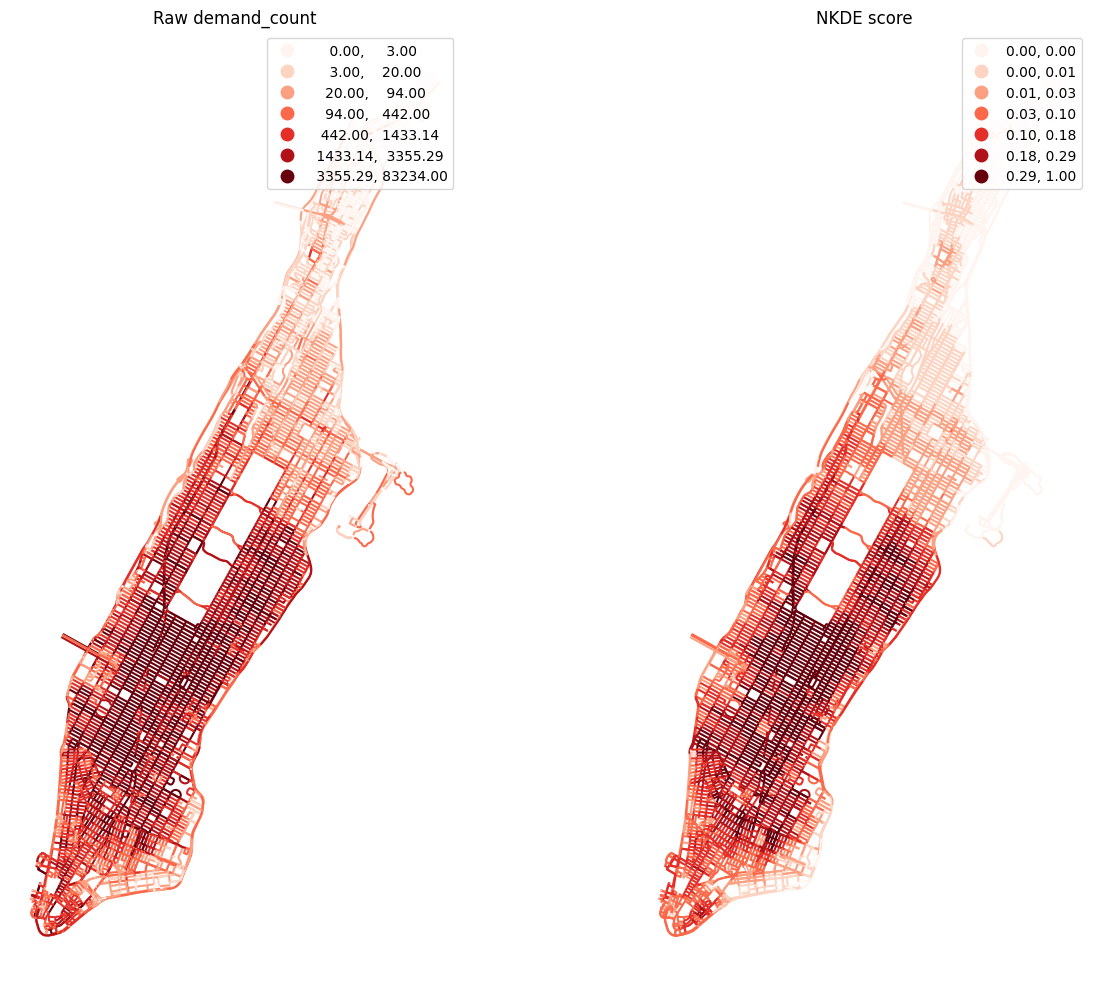

Saved -> C:\Users\Arv\OneDrive\Desktop\nyc-av-pudo-index\data\outputs\nkde_comparison.png


In [20]:
# Check 3: verify the spatial pattern of the NKDE scores
from pathlib import Path

import matplotlib.pyplot as plt

_root = Path.cwd()
if _root.name == "notebooks":
    _root = _root.parent
out_dir = _root / "data/outputs"
out_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 10))

edges.plot(
    column="demand_count",
    cmap="Reds",
    scheme="quantiles",
    k=7,
    legend=True,
    ax=axes[0],
)
axes[0].set_title("Raw demand_count")
axes[0].axis("off")

edges.plot(
    column="nkde_score",
    cmap="Reds",
    scheme="quantiles",
    k=7,
    legend=True,
    ax=axes[1],
)
axes[1].set_title("NKDE score")
axes[1].axis("off")

plt.tight_layout()
out_path = out_dir / "nkde_comparison.png"
plt.savefig(out_path, dpi=150)
plt.show()
print(f"Saved -> {out_path.resolve()}")

In [21]:
#Check 4: Score distribution
print(edges['nkde_score'].value_counts(bins=10, sort=False))
print(f"\nEdges with nkde_score = 0: {(edges['nkde_score'] == 0).sum()}")
print(f"Edges with nkde_score > 0.5: {(edges['nkde_score'] > 0.5).sum()}")
print(f"Edges with nkde_score = 1.0: {(edges['nkde_score'] == 1.0).sum()}")

(-0.002, 0.1]    5624
(0.1, 0.2]       1793
(0.2, 0.3]       1258
(0.3, 0.4]        699
(0.4, 0.5]        350
(0.5, 0.6]        148
(0.6, 0.7]         36
(0.7, 0.8]          4
(0.8, 0.9]          0
(0.9, 1.0]          4
Name: count, dtype: int64

Edges with nkde_score = 0: 2
Edges with nkde_score > 0.5: 192
Edges with nkde_score = 1.0: 1
